## Objective
Build and evaluate machine learning models to predict house prices based on
structural, locational, and amenity-based features, and identify the key
drivers of price variation.

## Dataset Information
The dataset contains 545 housing records with 13 attributes including area,
number of bedrooms/bathrooms, stories, parking, and binary amenity indicators
(main road access, guest room, basement, hot water heating, air conditioning,
preferred area) along with furnishing status.

## Workflow
Data loading, exploratory analysis, feature engineering, encoding, model
training (Linear Regression, Random Forest), evaluation,
and interpretation of feature importance.

# **Load Modules**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# **Load Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv')

print("Shape:", df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [4]:
df.sample(5, random_state=42)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,4060000,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6650000,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,3710000,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,6440000,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,2800000,3960,3,1,1,yes,no,no,no,no,0,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


## **Exploratory Data Analysis**

In [8]:
# Dataset Overview

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Data types summary:")
print(df.dtypes.value_counts())
print()
print("Memory usage:")
df.info(memory_usage='deep')

Number of rows: 545
Number of columns: 13

Data types summary:
object    7
int64     6
Name: count, dtype: int64

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 221.9 KB


In [9]:
# Missing Values

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
missing_df

,Missing Count,Missing Percentage
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [10]:
# Duplicate Rows

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (545, 13)


In [11]:
# Unique Values in Categorical Columns

categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


In [12]:
# Numerical Summary 
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

summary = df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
summary['Q1'] = df[numerical_cols].quantile(0.25)
summary['Q3'] = df[numerical_cols].quantile(0.75)
summary

,mean,median,std,min,max,Q1,Q3
price,4.766729e+06,4340000.0,1.870440e+06,1750000.0,13300000.0,3430000.0,5740000.0
area,5.150541e+03,4600.0,2.170141e+03,1650.0,16200.0,3600.0,6360.0
bedrooms,2.965138e+00,3.0,7.380639e-01,1.0,6.0,2.0,3.0
bathrooms,1.286239e+00,1.0,5.024696e-01,1.0,4.0,1.0,2.0
stories,1.805505e+00,2.0,8.674925e-01,1.0,4.0,1.0,2.0
parking,6.935780e-01,0.0,8.615858e-01,0.0,3.0,0.0,1.0


## **Univariate Analysis**

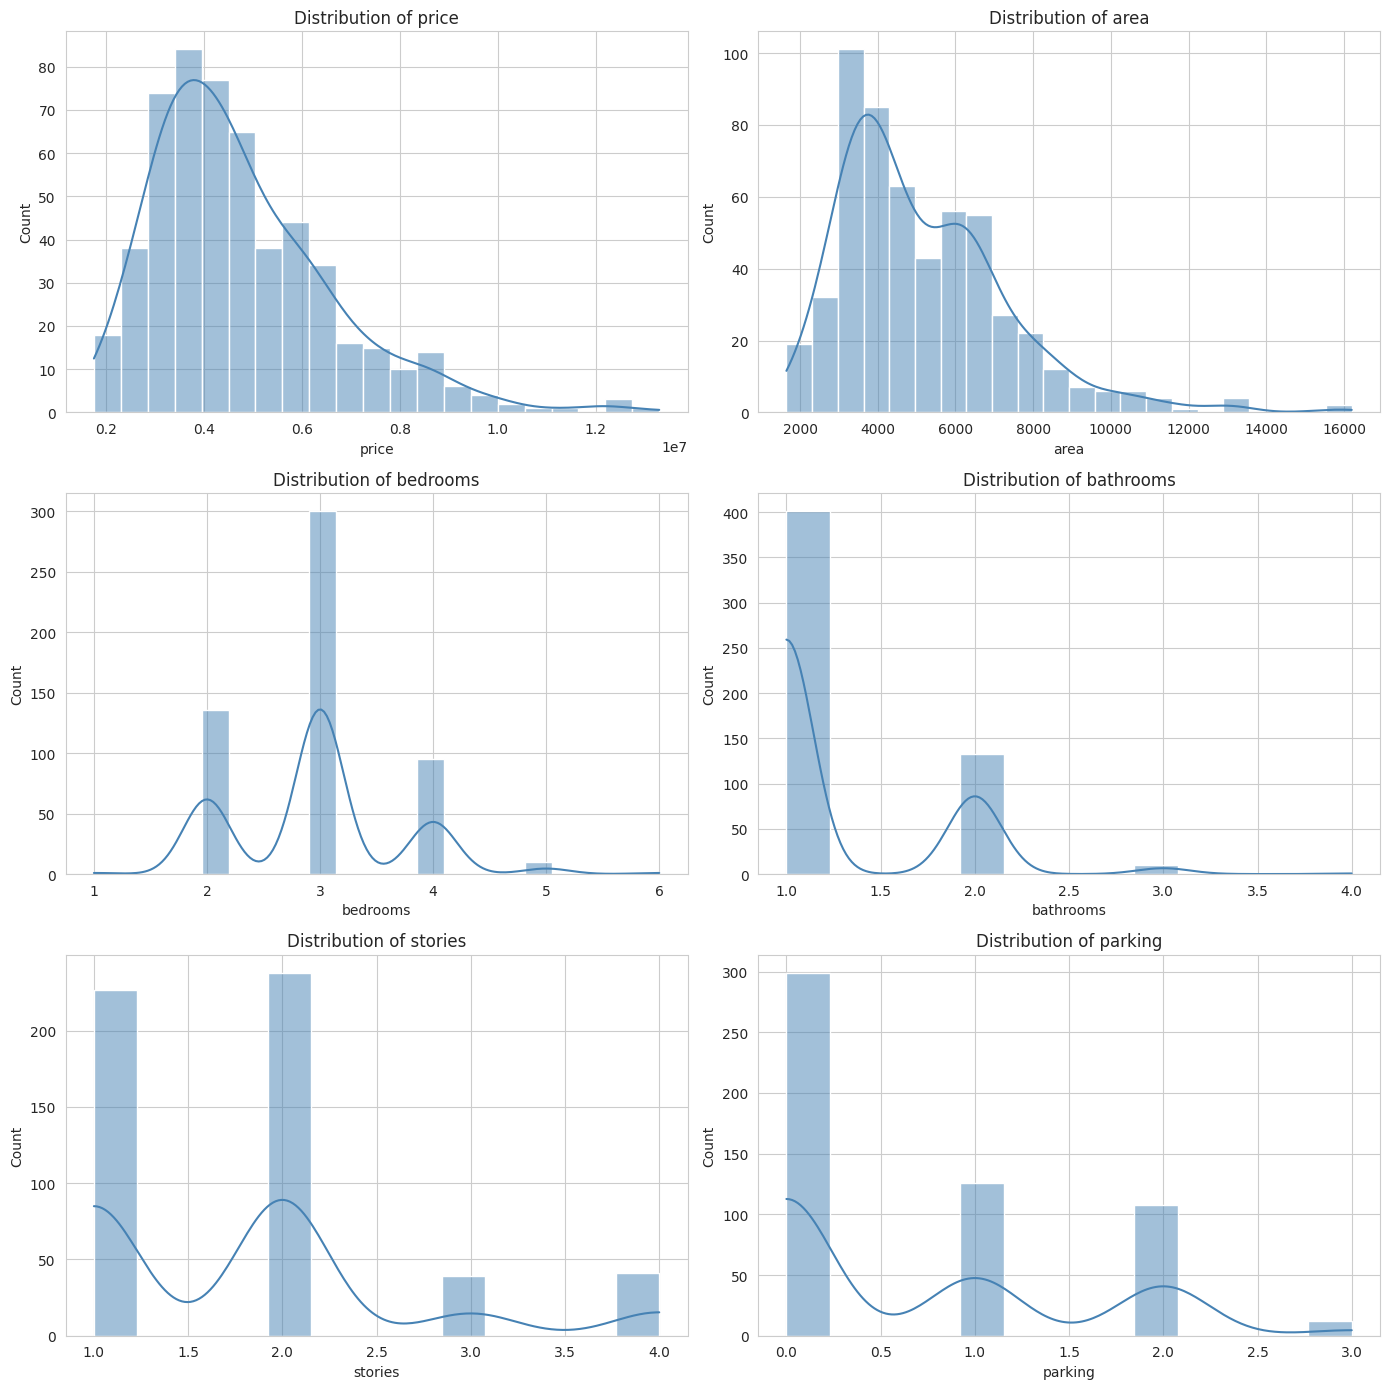

In [13]:
# Numerical Features

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

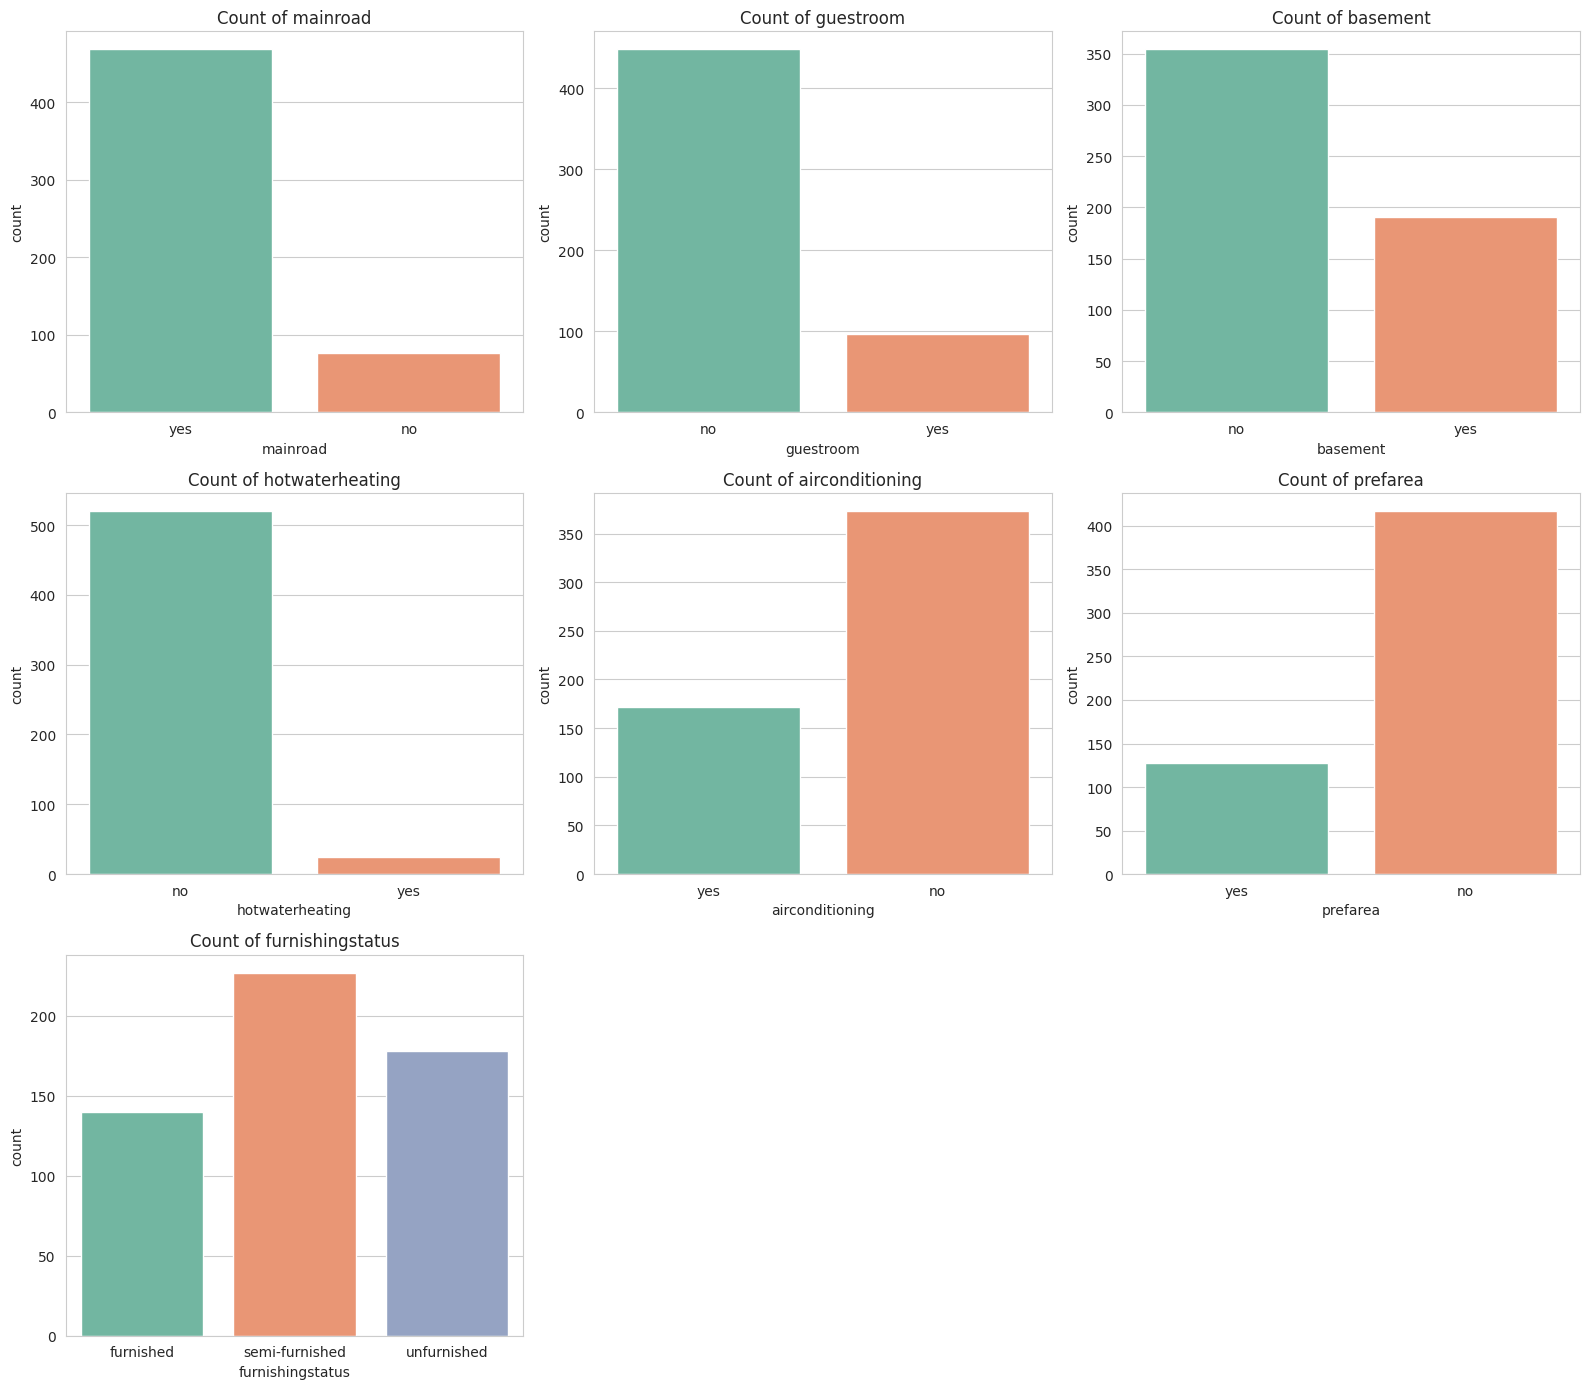

In [14]:
# Categorical Features

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Count of {col}')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Target Variable Analysis**

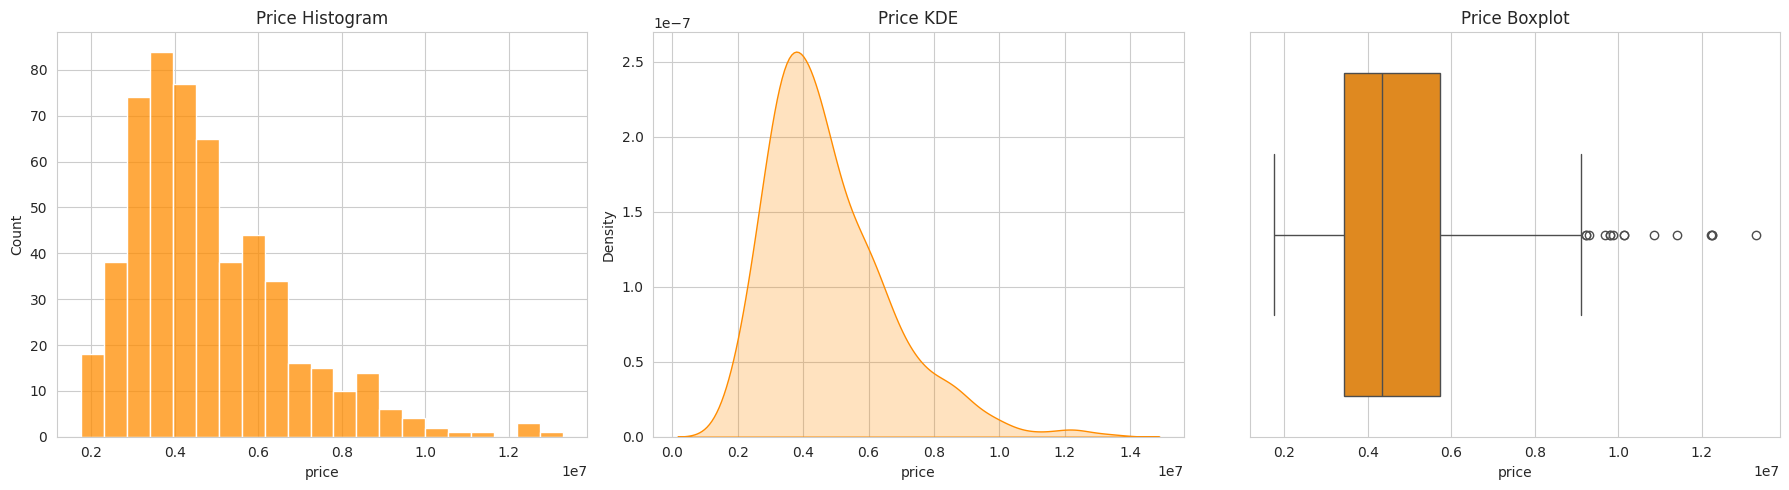

Skewness of price: 1.2122388370279802


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['price'], kde=False, ax=axes[0], color='darkorange')
axes[0].set_title('Price Histogram')

sns.kdeplot(df['price'], ax=axes[1], color='darkorange', fill=True)
axes[1].set_title('Price KDE')

sns.boxplot(x=df['price'], ax=axes[2], color='darkorange')
axes[2].set_title('Price Boxplot')

plt.tight_layout()
plt.show()

print("Skewness of price:", df['price'].skew())

The distribution of prices is skewed towards the right; there are relatively few high-end houses and many low to medium priced houses. The boxplot also shows that there are some houses that are priced much higher than the upper quartile, but this is not an error in the data as it is likely a high-end listing.

## **Bivariate Analysis**  

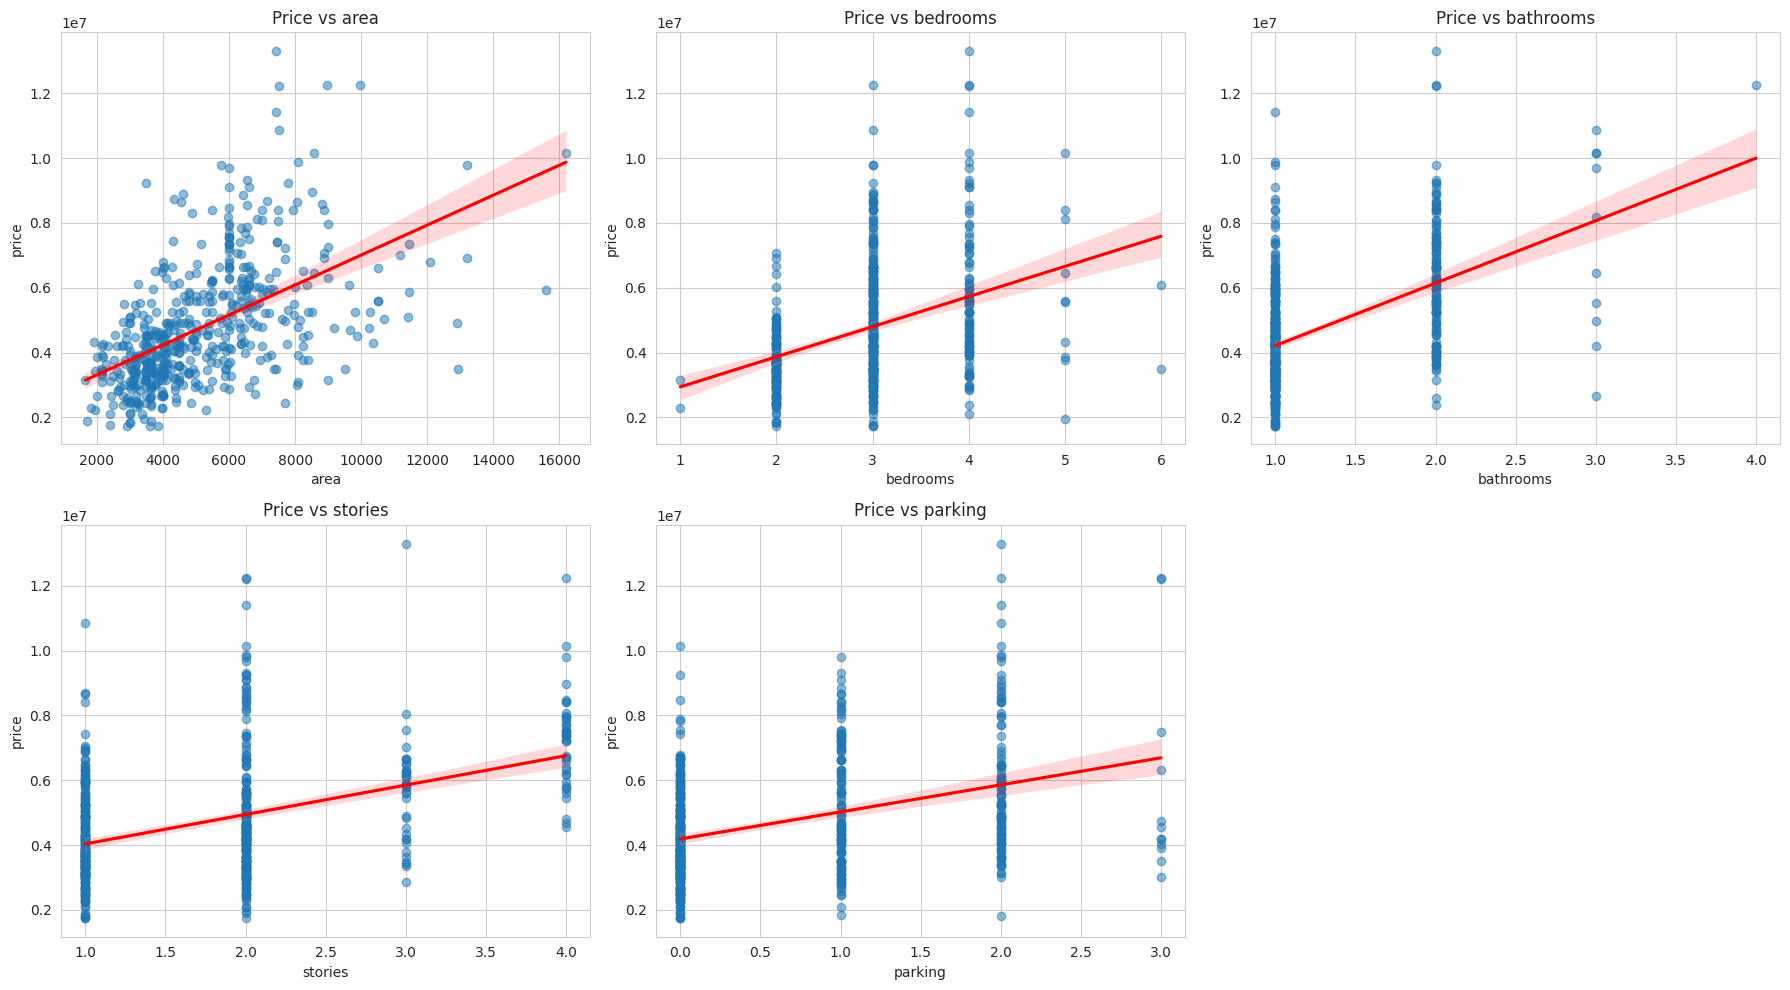

In [16]:
features_vs_price = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_vs_price):
    sns.regplot(x=col, y='price', data=df, ax=axes[i],
                scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    axes[i].set_title(f'Price vs {col}')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## **Categorical Analysis**

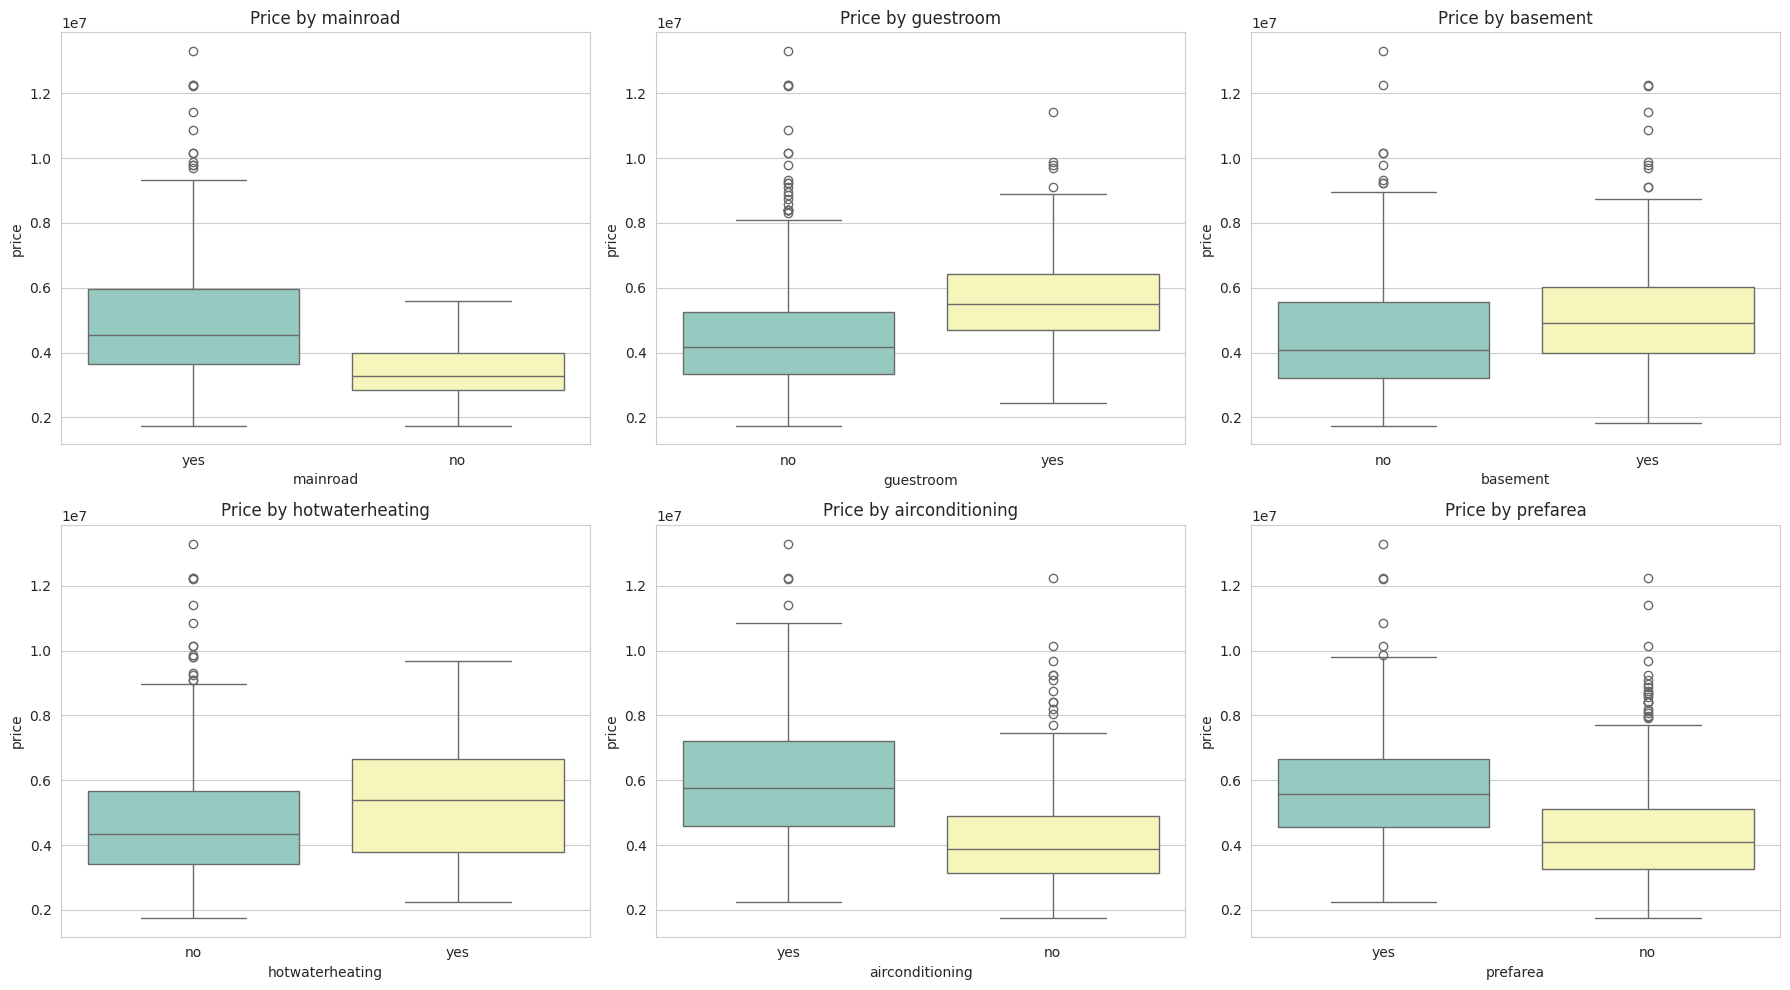

In [17]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='Set3')
    axes[i].set_title(f'Price by {col}')

plt.tight_layout()
plt.show()

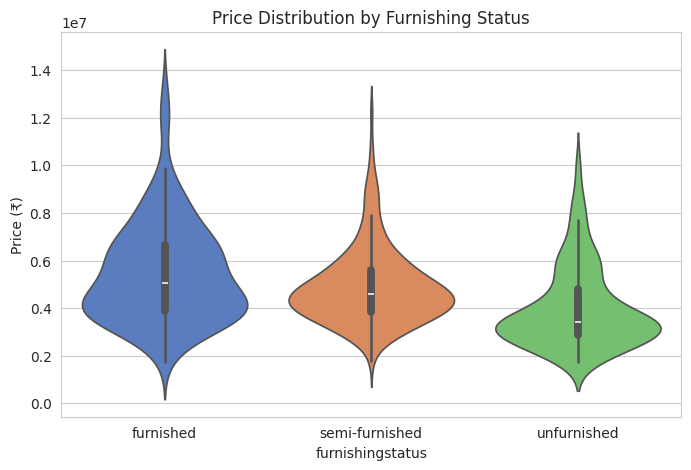

In [18]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='furnishingstatus', y='price', data=df, palette='muted')
plt.title('Price Distribution by Furnishing Status')
plt.ylabel('Price (₹)')
plt.show()

## **Correlation Analysis**

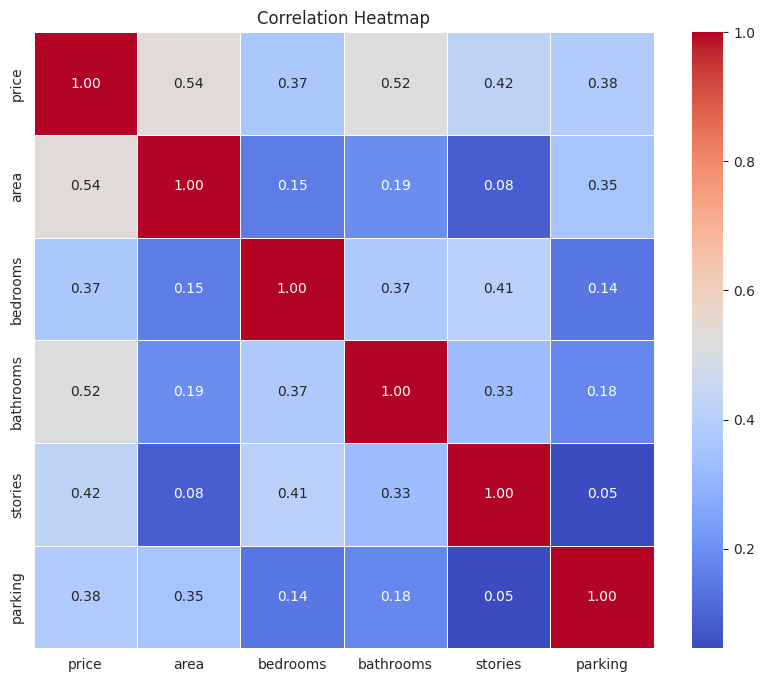

In [19]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
price_corr_table = pd.DataFrame({'Feature': price_corr.index, 'Correlation': price_corr.values})
price_corr_table

,Feature,Correlation
0,area,0.535997
1,bathrooms,0.517545
2,stories,0.420712
3,parking,0.384394
4,bedrooms,0.366494


## **Outlier Detection**

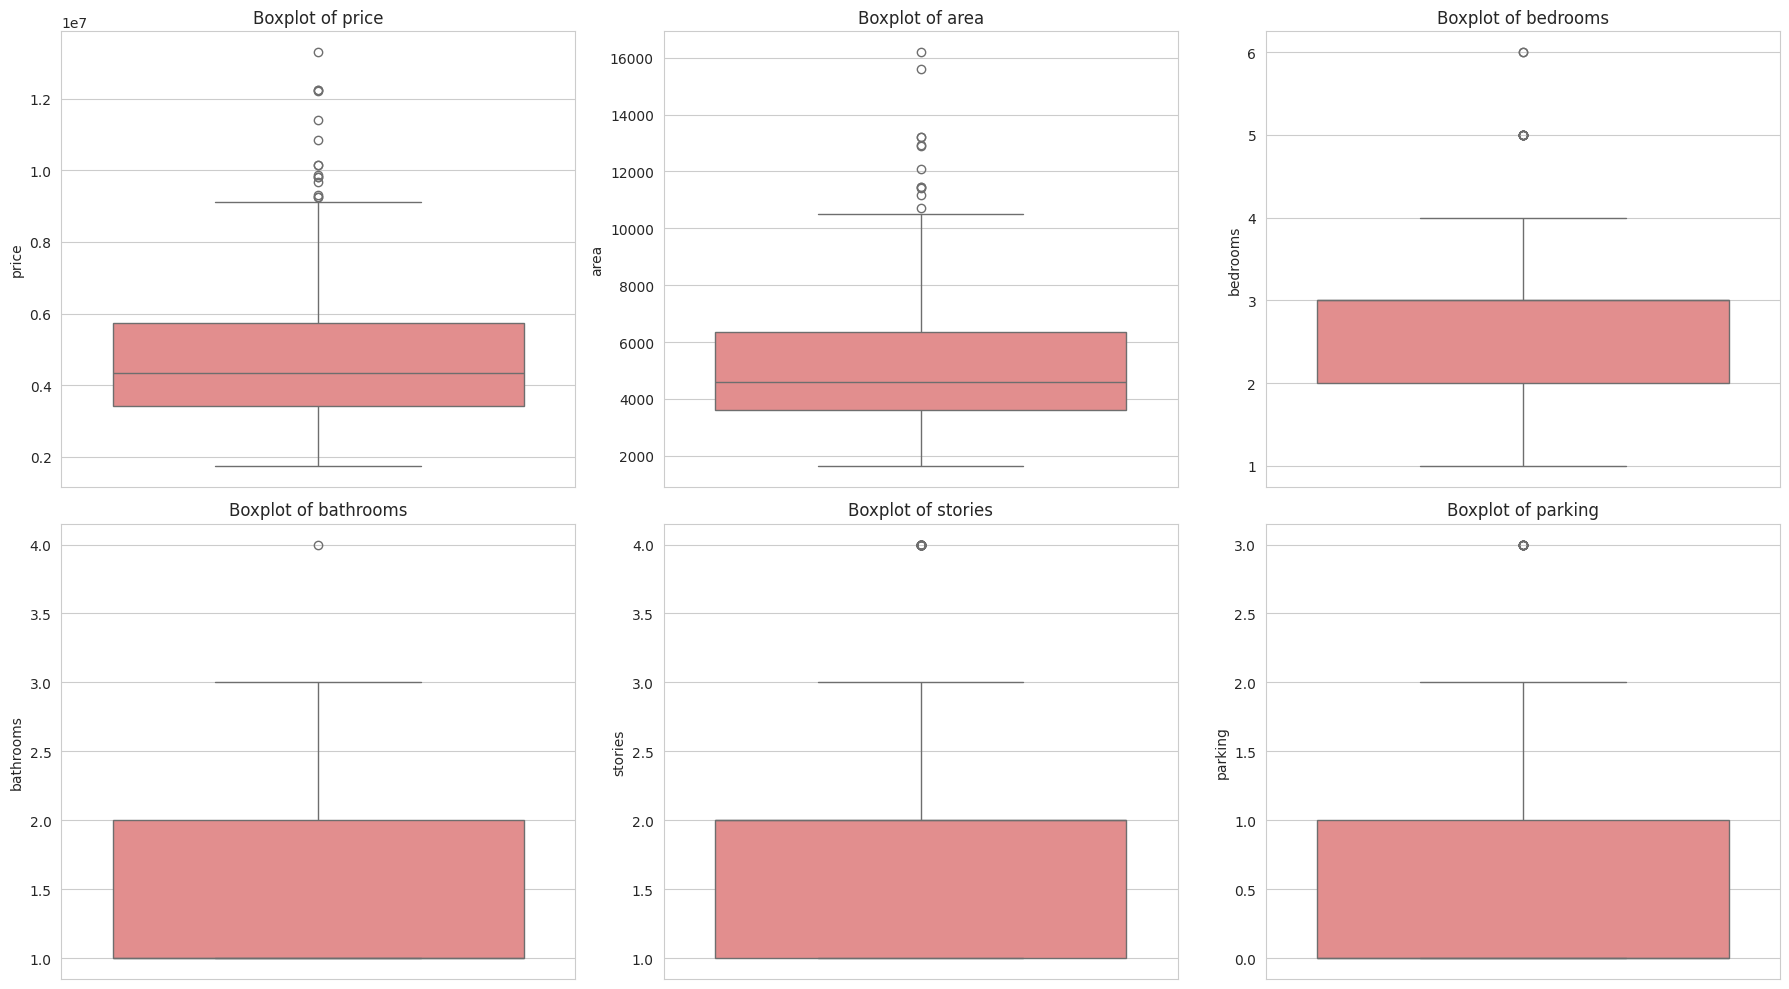

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Outliers exist for area and price; however, these pertain to correct large houses and not incorrect ones within the data set. Outliers are kept because the data set is relatively small (545 observations) and relatively clean.

## **Feature Engineering**

In [22]:
df_fe = df.copy()

df_fe['TotalRooms'] = df_fe['bedrooms'] + df_fe['bathrooms']
df_fe['AreaPerBedroom'] = df_fe['area'] / df_fe['bedrooms']
df_fe['AreaPerBathroom'] = df_fe['area'] / df_fe['bathrooms']

amenity_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df_fe['AmenityScore'] = df_fe[amenity_cols].apply(lambda x: (x == 'yes').sum(), axis=1)

df_fe['LuxuryScore'] = (
    df_fe['AmenityScore'] +
    (df_fe['furnishingstatus'] == 'furnished').astype(int) +
    (df_fe['parking'] > 0).astype(int)
)

df_fe.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,TotalRooms,AreaPerBedroom,AreaPerBathroom,AmenityScore,LuxuryScore
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,6,1855.0,3710.0,3,5
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,8,2240.0,2240.0,2,4
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,5,3320.0,4980.0,3,4
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,6,1875.0,3750.0,4,6
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5,1855.0,7420.0,4,6


## **Encoding**

In [23]:
binary_cols_present = [col for col in binary_cols if col in df_fe.columns]

df_fe = pd.get_dummies(df_fe, columns=binary_cols_present, drop_first=True)
df_fe = pd.get_dummies(df_fe, columns=['furnishingstatus'], drop_first=True)

df_fe.head()

,price,area,bedrooms,bathrooms,stories,parking,TotalRooms,AreaPerBedroom,AreaPerBathroom,AmenityScore,LuxuryScore,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,6,1855.0,3710.0,3,5,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,8,2240.0,2240.0,2,4,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,5,3320.0,4980.0,3,4,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,6,1875.0,3750.0,4,6,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,5,1855.0,7420.0,4,6,True,True,True,False,True,False,False,False


## **Feature Selection**

In [24]:
X = df_fe.drop('price', axis=1)
y = df_fe['price']

corr_with_target = df_fe.corr()['price'].drop('price').sort_values(ascending=False)
print("Correlation with price:")
print(corr_with_target)

variances = X.var().sort_values(ascending=False)
print("\nFeature variances:")
print(variances)

Correlation with price:
LuxuryScore                        0.617903
AmenityScore                       0.552954
area                               0.535997
bathrooms                          0.517545
TotalRooms                         0.511809
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
AreaPerBedroom                     0.244809
basement_yes                       0.187057
AreaPerBathroom                    0.139042
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

Feature variances:
area                               4.709512e+06
AreaPerBathroom                    4.504376e+06
AreaPerBedroom                     7.040

Each one of the kept variables is retained because each of them has a non-negligible correlation with the price, or provides important structural or amenity information (the area, number of rooms, bathrooms and engineered features are used for this purpose; the binary amenity variables are used to account for comfort and convenience factors).

## **Train-Test Split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (436, 18)
Test shape: (109, 18)


## **Model 1: Linear Regression**

In [26]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 963133.2588365647
RMSE: 1305637.265685281
R2: 0.6627431044659351


## **Model 2: Random Forest**

In [27]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 986089.8567278286
RMSE: 1364338.7470213338
R2: 0.6317352166656849


# **Save Model**

In [35]:
import joblib

joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Models saved successfully")

Models saved successfully


## **Model Comparison**

In [28]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Lakhs)': [round(mae_lr / 1e5, 2), round(mae_rf / 1e5, 2)],
    'RMSE (Lakhs)': [round(rmse_lr / 1e5, 2), round(rmse_rf / 1e5, 2)],
    'R2': [round(r2_lr, 4), round(r2_rf, 4)]
})

results = results.sort_values('R2', ascending=False).reset_index(drop=True)
results

,Model,MAE (Lakhs),RMSE (Lakhs),R2
0,Linear Regression,9.63,13.06,0.6627
1,Random Forest,9.86,13.64,0.6317


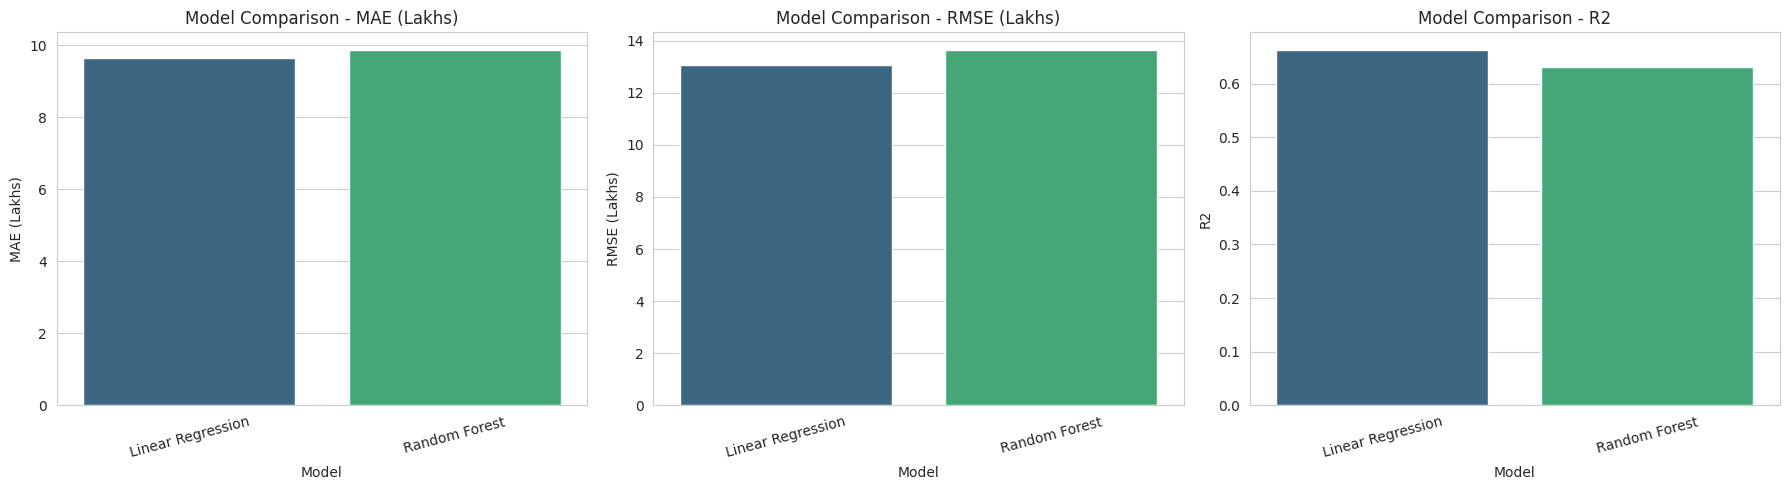

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE (Lakhs)', 'RMSE (Lakhs)', 'R2']

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=results, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Model Comparison - {metric}')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Model accuracy in plain terms:** In simple terms, the predictions made by the Linear Regression model were off by approximately ₹9.6 lakh. Also, it could account for about 66% of the variation in house prices, which means that two-thirds of the difference in the prices that houses are priced at can be explained by the features used here.

**What surprised you:** The fact that the model that is much more complex and powerful than Linear Regression (Random Forest) did not outperform the simpler model on this data was another surprise: On this data, the price seems to behave in a relatively simple manner with little complex interaction among features.

## **Feature Importance**

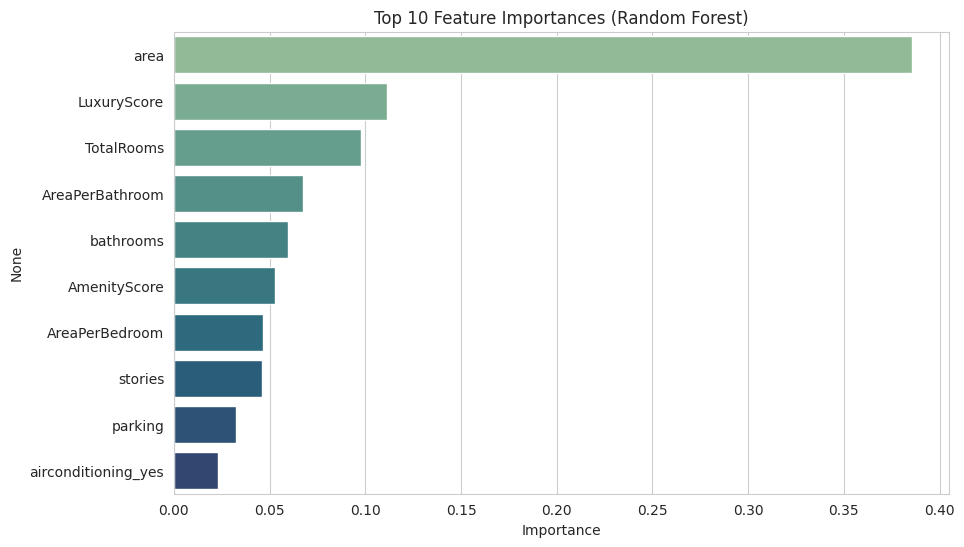

In [30]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='crest')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

## **Prediction Visualization**

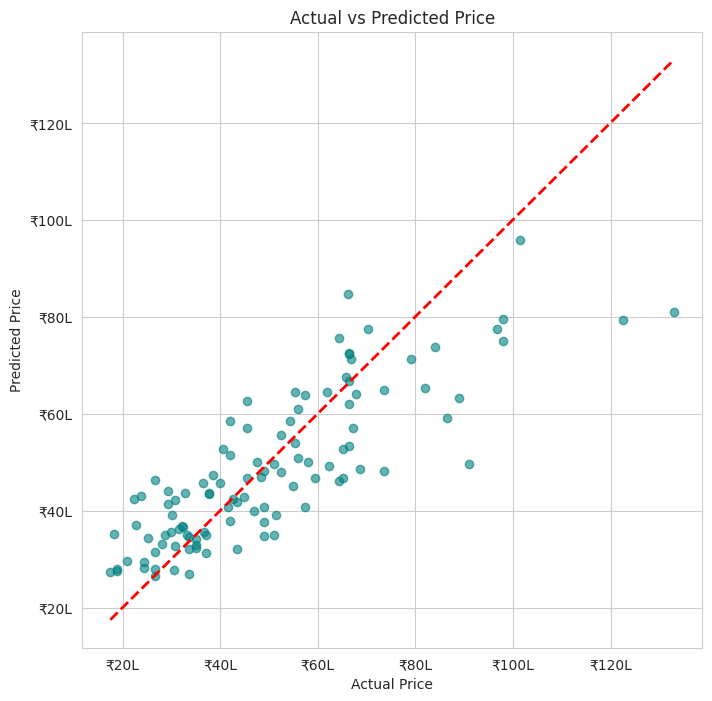

In [31]:
best_pred = y_pred_lr if r2_lr >= r2_rf else y_pred_rf

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')

import matplotlib.ticker as mticker

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
plt.show()

## **Residual Analysis**

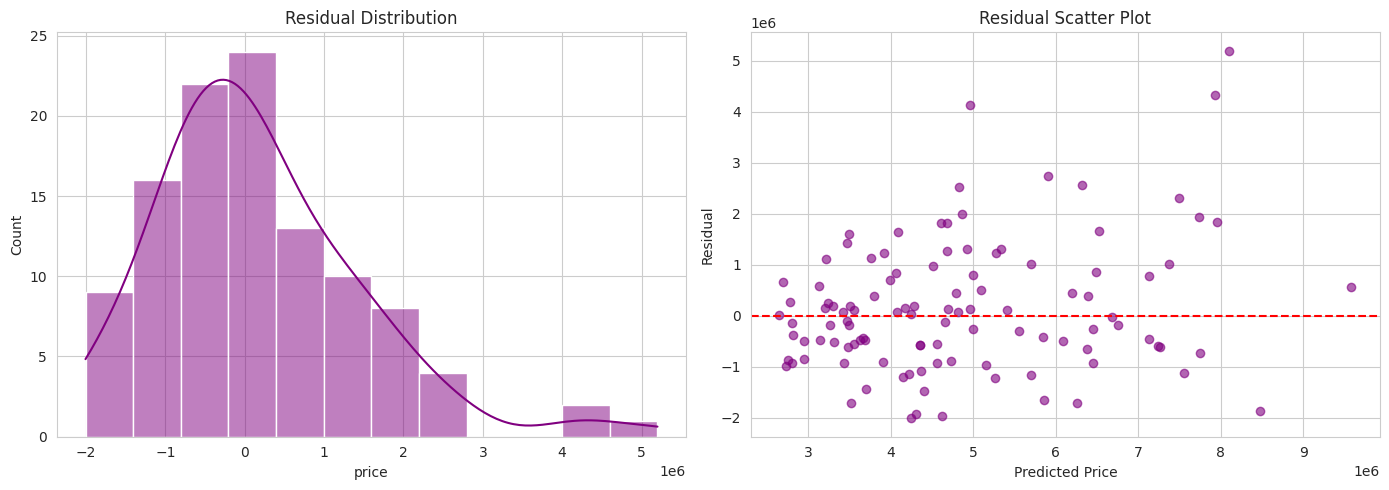

In [32]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Residual Distribution')

axes[1].scatter(best_pred, residuals, alpha=0.6, color='purple')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Scatter Plot')

plt.tight_layout()
plt.show()

## **Final Insights**

The features bathroom, location preference, and area were the three top most influential predictors of the price of houses. The houses that were distinguishable due to their larger area and having luxurious facilities like air conditioning and being located near desirable places could fetch more prices. Other secondary but not insignificant effects were noted due to the furnished status of houses and presence of parking spots. In this case, the performance of Linear Regression was better compared to Random Forest.

## **Conclusion**

**Business Recommendations:** When marketing properties, it is best to emphasize the area and number of bathrooms when marketing properties. Unfurnished and semi-furnished homes in not as ideal of an area may be better choices for value.

**Model Comparison:** The linear relationship between price and features on this dataset was slightly better than the Random Forest classifier, suggesting that the relationship here is mostly linear at this size of data. This underscores the fact that simpler models can be competitive to, if not better than, more complicated ensembles for small, well-structured, clean datasets.

**Future Work:** Future versions may incorporate additional data sets, geographic information (such as proximity to the city center), and the finer-grained amenity data to enhance predictive precision even more.